# SMART-CART Clustering System Project

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Collection

In [81]:
df = pd.read_csv("data/smartcart_customers.csv")

# Data Understanding

In [82]:
df.head()
df.shape
df.isnull().sum()

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data Preprocessing

# 1 ) Handling Missing Data

In [83]:
from sklearn.impute import SimpleImputer

numeric_impute = SimpleImputer(strategy = "median")

df[["Income"]] = numeric_impute.fit_transform(df[["Income"]])

# 2 ) Feature Engineering

In [84]:
# (a) Converting Birth Year to New Age Column of Customer

df["Age"] = 2026 - df["Year_Birth"]



In [85]:
# (b) Converting the Joining date of customer into Days

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst = True)

refrence_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = ( refrence_date - df["Dt_Customer"]).dt.days

In [86]:
# (c) Creating an Total Spending with sum of all products 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [87]:
# (d) Creating an Total Childrens with sum of all products 

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [88]:
# (e) Replacing education categories into 3 only

df["Education"].value_counts()


df["Education"] = df["Education"].replace({
    "Basic" : "UnderGraduate" , "2n Cycle" : "UnderGraduate" , 
    "Graduation" : "Graduate" , "Master" : "PostGraduate" , "PhD" : "PostGraduate"
})
    


In [89]:
# (f) Replacing MArtial categories into 3 only

df["Marital_Status"].value_counts()


df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner" , 
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone" , "Absurd" : "Alone" , "YOLO" : "Alone"
})
    

# Drop Unecessary Columns

In [90]:
cols = ["ID" , "Year_Birth" , "Dt_Customer" , "Kidhome" , "Teenhome" ]
spending_cols = ["MntWines" , "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds"]


cols_to_drop = cols + spending_cols

df_cleaned = df.drop(cols_to_drop , axis = 1)

# Detect and Handle Outliers

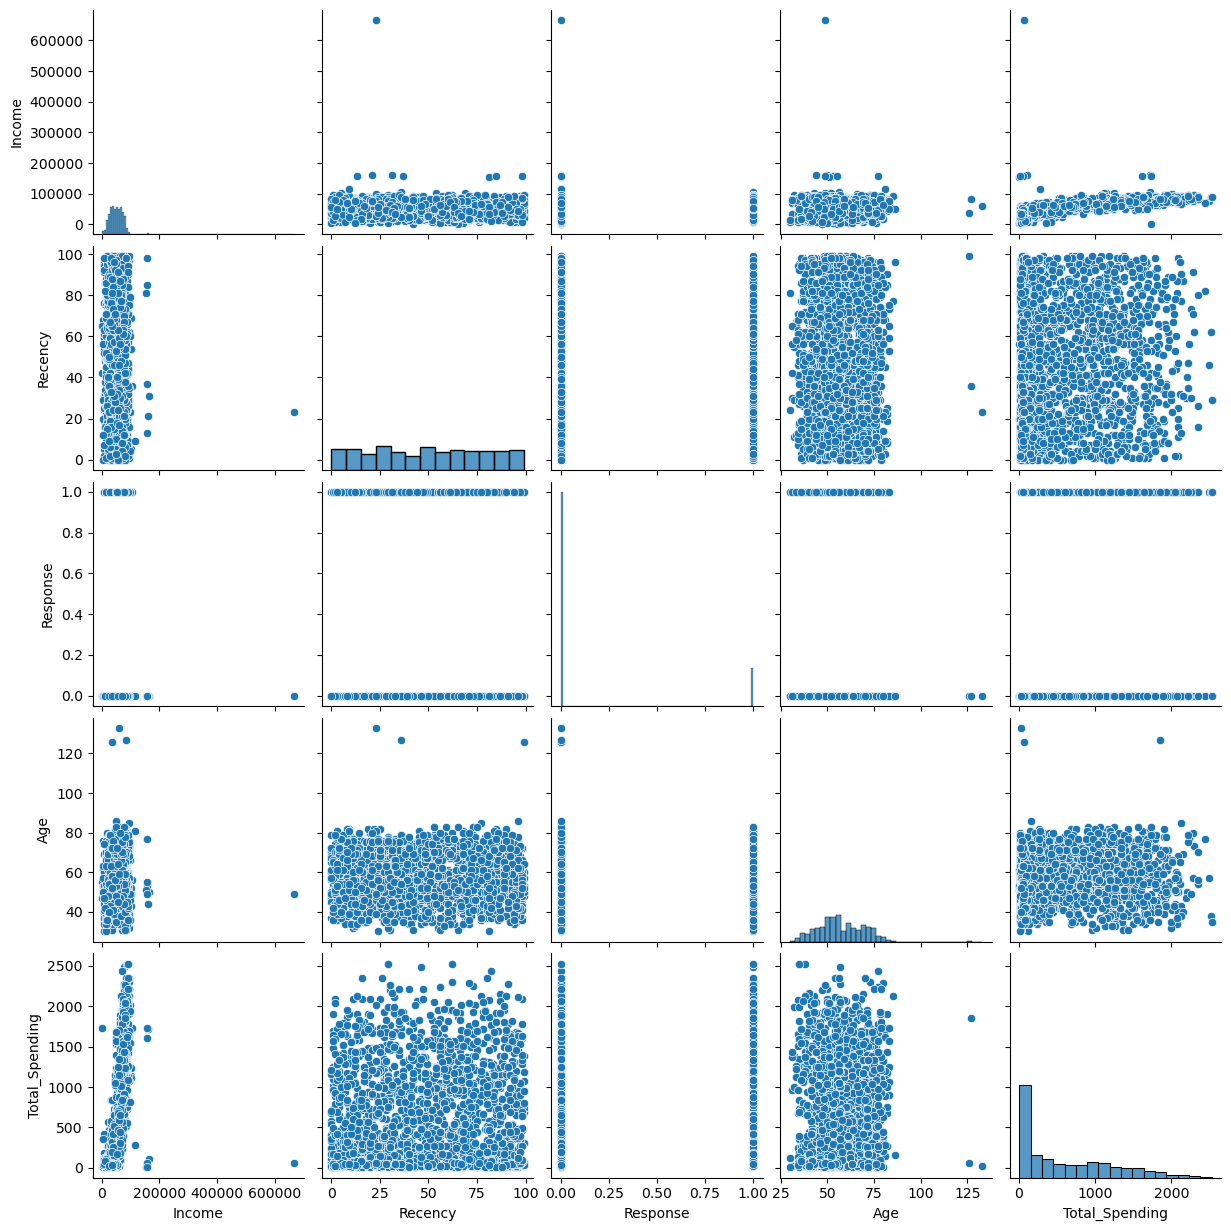

In [91]:
# First Visualize and see which are outliers

cols = ["Income" , "Recency" , "Response" , "Age" , "Total_Spending"]

sns.pairplot(df[cols])

In [92]:
# Second Remove Outliers

print("Data size with Outlier : ",len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]



print("Data size with Outlier : ",len(df_cleaned))

Data size with Outlier :  2240
Data size with Outlier :  2236


# Creating HeatMap of our Features

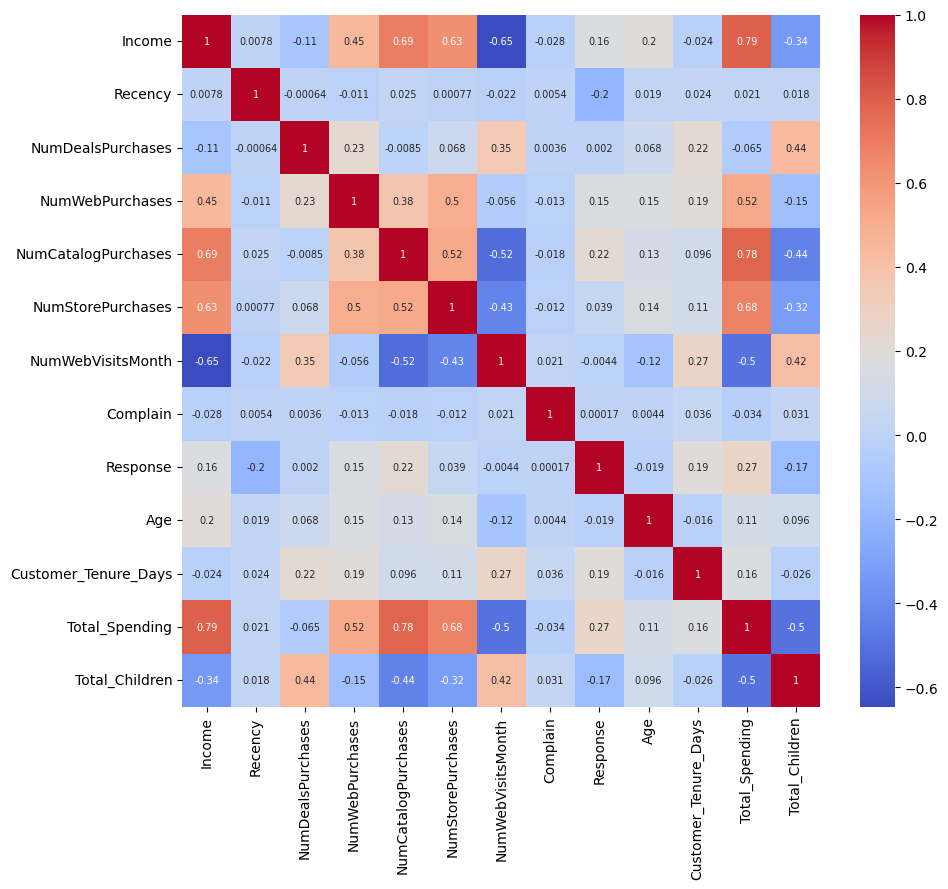

In [93]:
# Checking first co-orealtion

corr_matrix = df_cleaned.corr(numeric_only = True)

plt.figure(figsize = (10 , 9))

sns.heatmap(
    corr_matrix,
    cmap = "coolwarm",
    annot = True,
    annot_kws = {"size" : 7}
)

plt.tight_layout()

# Feature Scaling and Encoding

In [94]:
df_cleaned.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,Together,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,Together,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [95]:
drop_col = ["Marital_Status"]

df_cleaned = df_cleaned.drop(drop_col , axis = 1)

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


# Encoding of features
cols = ["Education" , "Living_With" ]

ohe = OneHotEncoder()

encoded_columns = ohe.fit_transform(df_cleaned[cols])

enc_df = pd.DataFrame(encoded_columns.toarray() , columns = ohe.get_feature_names_out(cols) , index = df_cleaned.index )

new_data = pd.concat([df_cleaned.drop(columns = cols) , enc_df] , axis = 1)




# Scaling of Features
X = new_data


In [97]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visulaizing Our Data

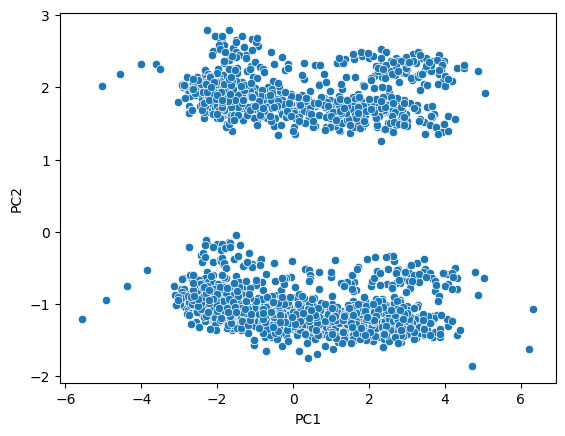

<Figure size 1000x800 with 0 Axes>

In [98]:
# So we cannot visualize the 18 dimensionb or features at a time so we have to do PCA to reduce its dimension

# 2D visualization

from sklearn.decomposition import PCA

pca_model = PCA(n_components = 3)

X_pca = pca_model.fit_transform(X_scaled)



sns.scatterplot(x = X_pca[:,0] , y = X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.figure(figsize = (10,8))
plt.tight_layout()



Text(0.5, 0.92, '3D Projection')

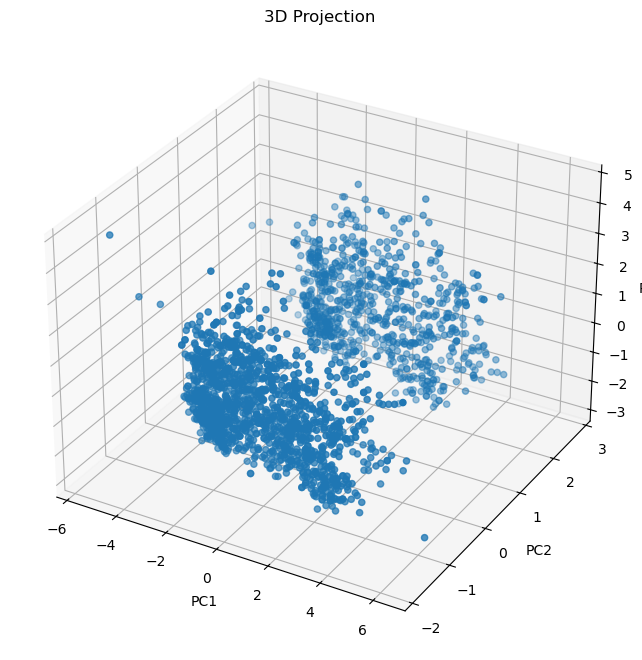

In [99]:
# 3D visualization
fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

# Now Use Clustering Algorithms

# [A] Analyze k value

In [100]:
# 1 Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    k_means = KMeans(n_clusters = k , random_state = 42)
    k_means.fit_predict(X_pca)

    wcss.append(k_means.inertia_)
    
    

<Axes: >

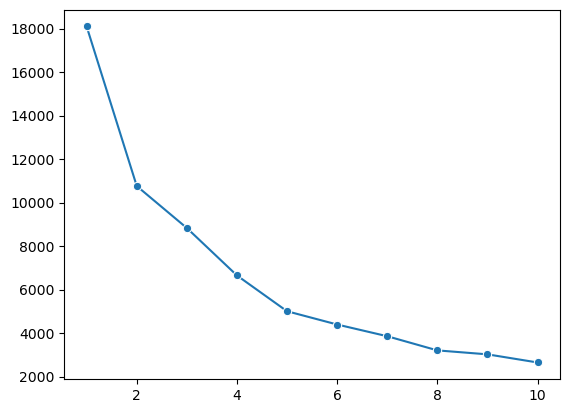

In [101]:
sns.lineplot(x = range(1,11) , y = wcss , marker = 'o')

In [102]:
knee = KneeLocator(range(1,11) , wcss , curve = "convex" , direction = "decreasing")
optimal_k = knee.elbow
print("Best k :" , optimal_k)

Best k : 4


<Axes: >

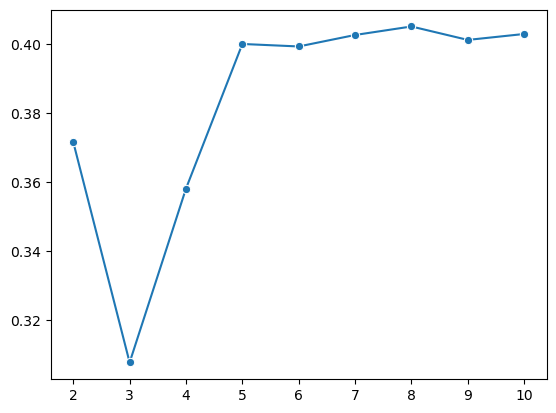

In [103]:
# 2 Silhoute Score

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    k_means = KMeans(n_clusters = k , random_state = 42)
    labels = k_means.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)



sns.lineplot(x = range(2,11) , y = scores , marker = 'o')

# [B] Apply Clustering Algorithms

# K-Means Clustering

In [104]:

# Model Training

k_means = KMeans(n_clusters = 4)
labels = k_means.fit_predict(X_pca)

<Axes: >

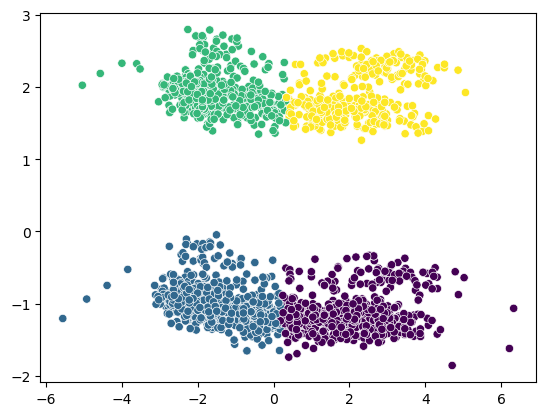

In [105]:
# 2D visualization

sns.scatterplot(x = X_pca[:,0] , y = X_pca[:,1] , c = labels)

Text(0.5, 0.92, '3D Projection')

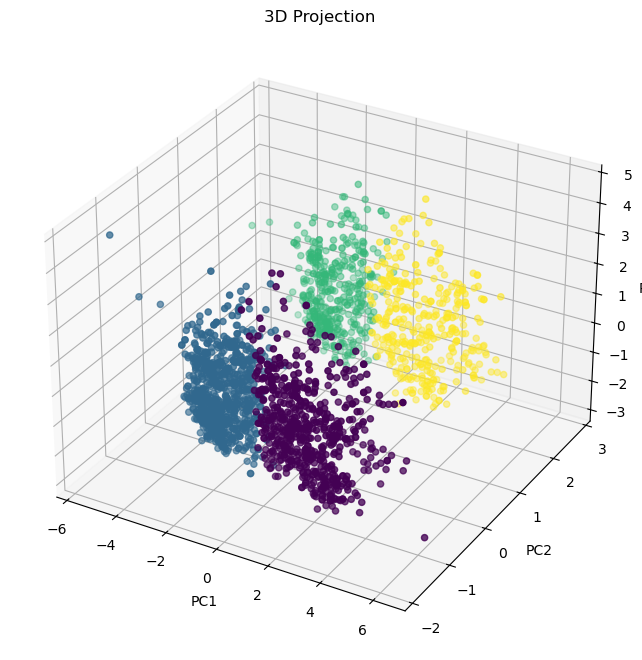

In [106]:
# 3D visualization

fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c = labels)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

# Hierarchical Clustering - Aggloremative

In [107]:
#Model Traning

from sklearn.cluster import AgglomerativeClustering

agglo_model = AgglomerativeClustering(n_clusters= 4)
labels2 = agglo_model.fit_predict(X_pca)


<Axes: >

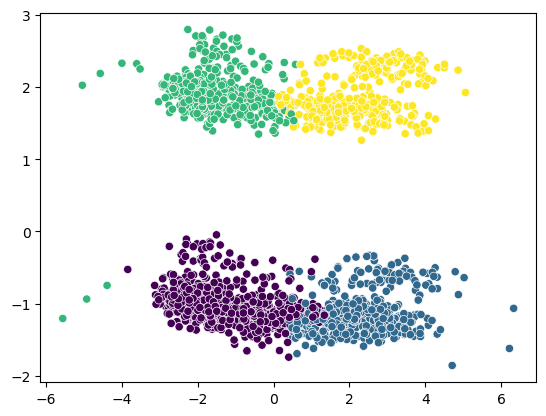

In [108]:
# 2D Visualization

sns.scatterplot(x = X_pca[:,0] , y = X_pca[:,1] , c = labels2)

Text(0.5, 0.92, '3D Projection')

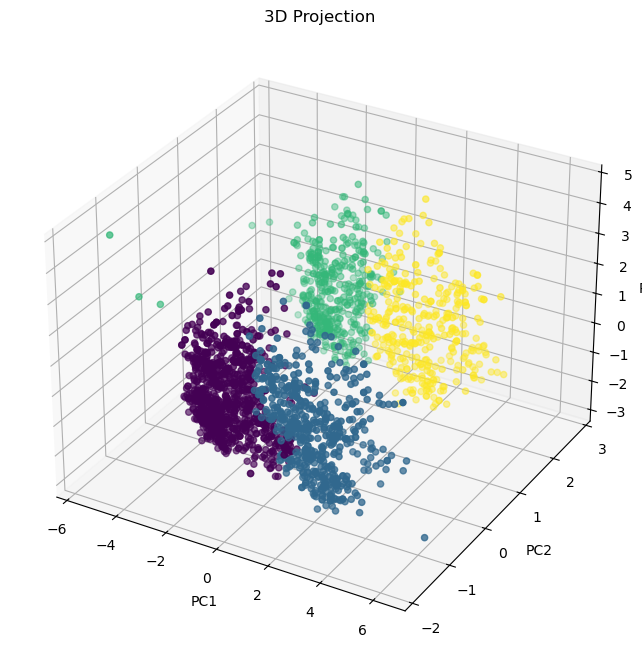

In [109]:
# 3D visualization
fig = plt.figure(figsize = (8,10))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c = labels2)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

# Characterization or Analyzing Clusters

In [110]:


X["clusters"] = labels2


In [111]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

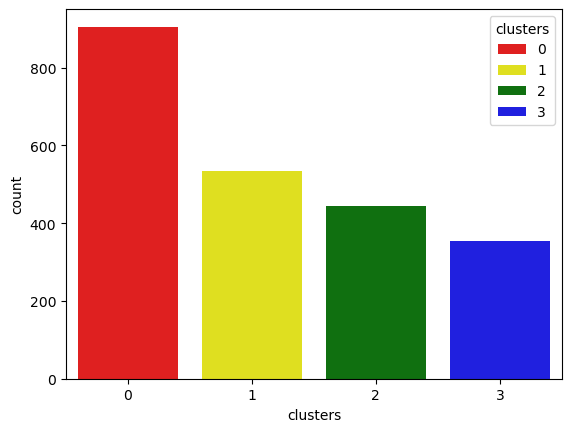

In [112]:
pal = ["red" , "yellow" , "green" , "blue"]
sns.countplot(x =X["clusters"] , palette = pal , hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

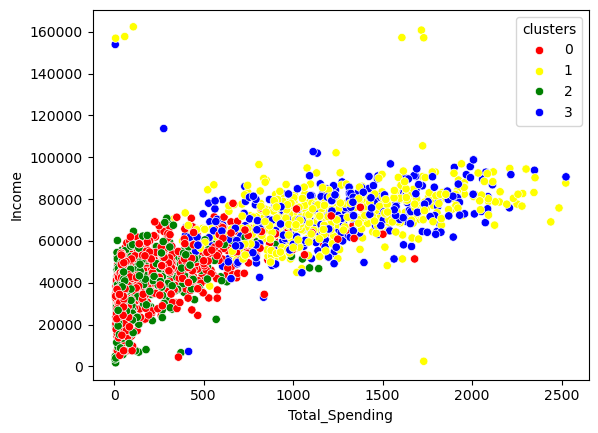

In [113]:
sns.scatterplot(x = X["Total_Spending"] , y = X["Income"] , hue = X["clusters"], palette = pal)

# Clusters Summary

In [114]:
cluster_summary = X.groupby("clusters").mean()
print("Summary for Clusters :",cluster_summary)

Summary for Clusters :                 Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days

# Extracting Model in Model Folder

In [115]:
import pickle


# Save model
pickle.dump(k_means, open("model/model.pkl", "wb"))

# Save scaler (if used)
pickle.dump(scaler, open("model/scaler.pkl", "wb"))

# Evaluation 

In [119]:
from sklearn.metrics import  davies_bouldin_score, calinski_harabasz_score


# Calculate clustering metrics
silhouette = silhouette_score(X_pca, k_means.labels_)
db_index = davies_bouldin_score(X_pca, k_means.labels_)
ch_index = calinski_harabasz_score(X_pca, k_means.labels_)


# Print the metric scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")


Silhouette Score: 0.40
Davies-Bouldin Index: 1.05
Calinski-Harabasz Index: 1387.57
